

---


# **Subject : Automatically categorize questions on Stackoverflow**





---











To ask a question un StackOverflow, people need to select some tags in order to maximize their chance to get an answer. In this project, we are volunteer to help StackOverflow by developping an algorithm that will suggest tags based on the title and/or the content of the question.

For doing this, we will need first get some data for training and testing our algorithms. StackOverflow offers a data export tool, "[StackExchange Data Explorer](https://data.stackexchange.com/stackoverflow/query/new)", which lists a large amount of authentic data from the platform.
Therefore you can run the following query in this data export tool to create your dataset and download it:

```
SELECT TOP 10000 Title, Body, Tags, Score, ViewCount, FavoriteCount, AnswerCount, CreationDate
FROM Posts
WHERE ViewCount > 10
AND AnswerCount > 5
AND LEN(Tags) - LEN(REPLACE(Tags, '<','')) <= 4
AND LEN(Tags) - LEN(REPLACE(Tags, '<','')) >= 1
```

If you can't download the data by yourself, you can use the files available in this link : [here](https://1drv.ms/f/c/ab584826bfa6bf60/EmC_pr8mSFgggKuwDgAAAAABUQ7Gb55TD9Sc_u27Dezm2A?e=0Tw5fz)


Below are the steps required to fullful this project :



1.   Process the "Tags" column in order to compute some statistics : wordcloud on the tags, bar diagram with the 20 most common tags
2.   Filter the dataset to keep only rows containing the top 10 tags
3.   Combine the title and the body of the question for the analysis. Apply cleaning process on the corpus (title+body)
4.   Implement an unsupervised approach (LDA for example) to identify main topics/key word on the dataset. Propose some graphics to illustrate the results
5.   Implement a supervised approach to predict the tags (use [this first example](https://www.kaggle.com/discussions/questions-and-answers/66693) to process the target into multiple binary outputs and [this second example](https://dongr0510.medium.com/multi-label-classification-example-with-multioutputclassifier-and-xgboost-in-python-98c84c7d379f) to know how to predicting a multilabel target). Make sure to test and compare the following feature extraction methods :

    *   1 bag-of-word approach : TF-IDF or CountVectorizer
    *   2 word embedding approach among these : Word2Vec, Glove, BERT, USE

  For the word embedding part, you can use [this example of notebook](https://s3.eu-west-1.amazonaws.com/course.oc-static.com/projects/Data_Scientist_P6/Exemple_Tweets_Feature-extraction_Sentence+Embedding_V1.1.ipynb) to help you explore Word2Vec, Doc2Vec, Glove, BERT et USE.

  For the supervised task, test 2 or more models and tune hyperparameters if possible.

6.   Evaluate and compare the models trained after using a train/test split


In [1]:
# Imports

In [2]:
# Packages needed for this notebook — uncomment and run once on a fresh environment (e.g. personal machine / Google Colab)
# %pip install pandas numpy matplotlib beautifulsoup4 nltk wordcloud scikit-learn gensim sentence-transformers xgboost

In [3]:
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import numpy as np
import re
import nltk
from bs4 import BeautifulSoup
nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))



Matplotlib is building the font cache; this may take a moment.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\khali\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\khali\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [4]:
df = pd.read_csv('QueryResults.csv')

In [5]:
df.head()

,Title,Body,Tags,Score,ViewCount,FavoriteCount,AnswerCount,CreationDate
0,How to override the properties of a CSS class ...,<p>I am fairly new to CSS3 and I want to be ab...,<css><class><overriding>,122,463698,0.0,6,2014-01-06 16:38:24
1,toString() of int e = 0000007 omits all zeros....,<p>I'm trying to write a program in C# that ta...,<c#><numbers><int>,2,668,0.0,9,2010-01-25 08:50:48
2,The fastest way to check if some records in a ...,<p>I have a huge table to work with . I want t...,<database><oracle><hibernate>,10,22104,0.0,6,2010-01-25 09:03:42
3,Can you make valid Makefiles without tab chara...,<pre><code>target: dependencies\n command1\...,<makefile><tabs><whitespace><spaces>,134,70813,0.0,10,2010-01-25 09:15:56
4,CSS - Margins a bad thing?,<p>I've noticed that some browsers have troubl...,<html><css><margin>,5,856,0.0,6,2010-01-25 09:03:52


### 1. **Processing "Tags"**

In [6]:
## Transform tags values into list of tags
def process_tag(s):
  return(list(filter(None, re.split(r'<|>' , s))))

df['tag_list'] =  df.Tags.apply(process_tag)
df[['Tags', 'tag_list']].head()

,Tags,tag_list
0,<css><class><overriding>,"[css, class, overriding]"
1,<c#><numbers><int>,"[c#, numbers, int]"
2,<database><oracle><hibernate>,"[database, oracle, hibernate]"
3,<makefile><tabs><whitespace><spaces>,"[makefile, tabs, whitespace, spaces]"
4,<html><css><margin>,"[html, css, margin]"


In [7]:
# Get list of all tags
l_tags = df.tag_list.apply(lambda x : " ".join(x)).tolist()
all_tags = " ".join(l_tags)
all_tags

'css class overriding c# numbers int database oracle hibernate makefile tabs whitespace spaces html css margin regex comparison formal-languages php mysql passwords encryption python documentation standard-library c# generics dictionary filtering java operators angular angular-cli ios objective-c uiview c# coding-style assert language-agnostic pointers null hex php string arrays casting spring-boot spring-cloud-netflix spring-cloud-config css user-interface sql python django java google-sheets google-sheets-api google-workspace ios swift ios10 html forms lastpass ruby instance-variables private-members java unit-testing homebrew formula wine macos-catalina java soap rest java java arraylist javascript null text macros text-editor forms delphi javascript jquery javascript regex javascript jquery text iphone mkmapview mkannotation java aop python list find indexing php cakephp cakephp-2.4 java equals hashcode language-agnostic design-patterns c# .net regex csv awk sed c# azure azure-keyv

In [8]:
# List of unique tags
unique_tags = np.unique(all_tags.split(' '))
len(unique_tags)

4000

In [9]:
# Count of occurence of tags
(pd.DataFrame(all_tags.split(' '), columns = ['tag'])\
  .groupby('tag').agg({'tag' : 'count'})\
  .rename(columns={'tag': 'count'})\
  .reset_index()\
  .sort_values('count', ascending = False)\
  .head(15))

,tag,count
456,c#,1198
1817,java,968
461,c++,668
2,.net,642
1834,javascript,623
2737,python,591
2576,php,490
3211,sql,367
1596,html,362
235,asp.net,359


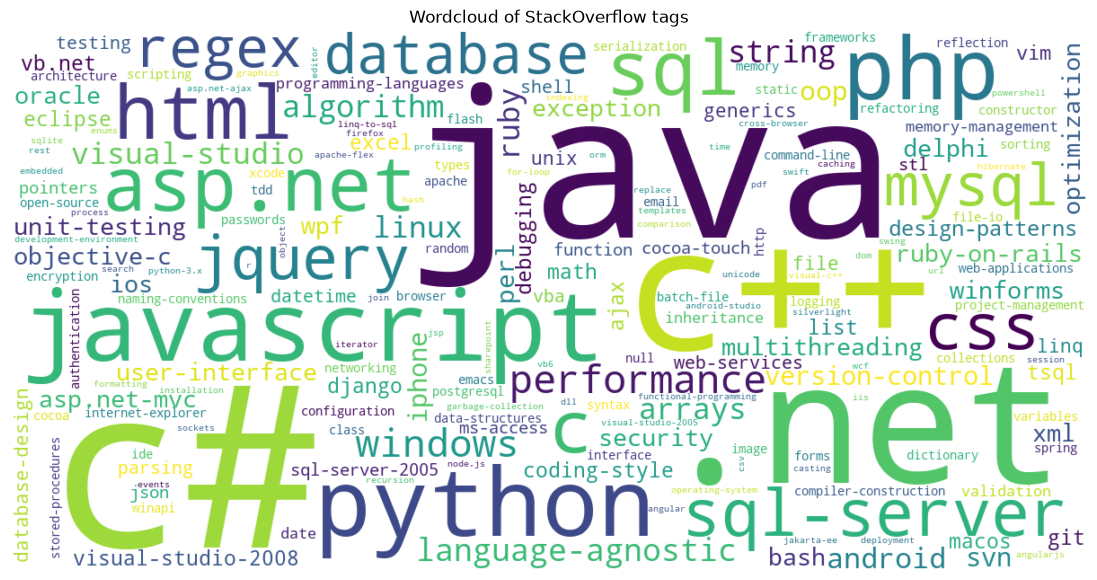

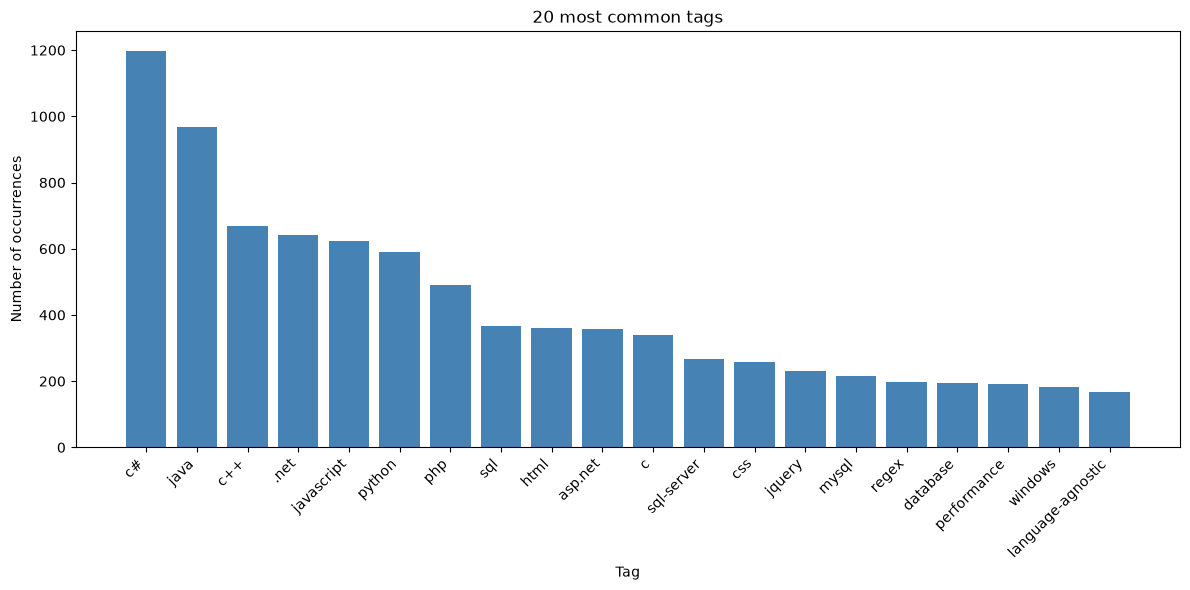

In [10]:
## TODO :=> wordcloud on the tags, bar diagram with the 20 most common tags
from wordcloud import WordCloud
from collections import Counter

tag_counts = Counter(all_tags.split(' '))

# Wordcloud on the tags
wc = WordCloud(width=1200, height=600, background_color='white', colormap='viridis')\
      .generate_from_frequencies(tag_counts)
plt.figure(figsize=(14, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Wordcloud of StackOverflow tags')
plt.show()

# Bar diagram with the 20 most common tags
top20 = pd.DataFrame(tag_counts.most_common(20), columns=['tag', 'count'])
plt.figure(figsize=(12, 6))
plt.bar(top20['tag'], top20['count'], color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Tag')
plt.ylabel('Number of occurrences')
plt.title('20 most common tags')
plt.tight_layout()
plt.show()

### 2. **Filter dataset**

In [11]:
## TODO :=> Take the real list of 10 most frequent tags
most_frequent_tags = [tag for tag, count in Counter(all_tags.split(' ')).most_common(10)]
print("Top 10 tags :", most_frequent_tags)

def intersection(lst1, lst2):
    return list(set(lst1) & set(lst2))

def keep_indicator(l_tags):
  intersect = intersection(l_tags, most_frequent_tags)
  return(int(len(intersect) > 0))

keep_indicator(['tag', "c"])

Top 10 tags : ['c#', 'java', 'c++', '.net', 'javascript', 'python', 'php', 'sql', 'html', 'asp.net']


0

In [12]:
# Create indicator for keeping row or not
df['keep_indicator'] = df['tag_list'].apply(keep_indicator)
df[['tag_list', 'keep_indicator']].head()

,tag_list,keep_indicator
0,"[css, class, overriding]",0
1,"[c#, numbers, int]",1
2,"[database, oracle, hibernate]",0
3,"[makefile, tabs, whitespace, spaces]",0
4,"[html, css, margin]",1


In [13]:
# Clean the tag_list for keeping only selected tags => this cleaned column will be used for modeling
def simplify_tag_list(l):
  return([x for x in l if x in most_frequent_tags])

df['tag_list_final'] = df['tag_list'].apply(simplify_tag_list)
df['n_tags'] = df['tag_list_final'].apply(lambda x : len(x))
df[['tag_list', 'keep_indicator', 'tag_list_final', 'n_tags']].sort_values('n_tags', ascending = False).head(5)

,tag_list,keep_indicator,tag_list_final,n_tags
2547,"[c#, .net, asp.net, javascript]",1,"[c#, .net, asp.net, javascript]",4
675,"[c#, .net, python]",1,"[c#, .net, python]",3
9525,"[c#, asp.net, sql, blogs]",1,"[c#, asp.net, sql]",3
9956,"[c#, .net, html, template-engine]",1,"[c#, .net, html]",3
285,"[c#, asp.net, html, asp.net-mvc]",1,"[c#, asp.net, html]",3


In [14]:
## TODO :=> Filter the dataset to keep only rows with selected tags
print("Shape before filtering :", df.shape)
df = df[df['keep_indicator'] == 1].reset_index(drop=True)
print("Shape after filtering  :", df.shape)
df['n_tags'].value_counts()

Shape before filtering : (10000, 12)
Shape after filtering  : (5447, 12)


n_tags
1    4676
2     722
3      48
4       1
Name: count, dtype: int64

### 3. **Cleaning process**

In [15]:
# TODO :=> complete the cleaning function to add classical cleaning process in NLP (prefer lemmatizing to stemming :)  )
# Concatenate Title & body, then clean
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

def remove_tags(text):
  soup = BeautifulSoup(text, "html.parser")
  for data in soup(['style', 'script']):
    data.decompose()
  return ' '.join(soup.stripped_strings)

def clean_text(text):
  s = text.lower() # Lowercase
  s = remove_tags(s) # remove html tags "<.>"
  s = re.sub('\n','', s) # remove line breaks
  s = re.sub(r'(&lt;)|(&gt;)','', s) # remove special sequences
  #... => other cleaning operations
  s = re.sub(r'http\S+|www\.\S+', ' ', s) # remove URLs
  s = re.sub(r'[^a-z#+\s]', ' ', s) # keep only letters ('#' and '+' kept to preserve tags like c# / c++)
  tokens = s.split() # tokenization
  tokens = [w for w in tokens if w not in stop_words] # remove stopwords
  tokens = [w for w in tokens if len(w) > 1] # remove single characters
  tokens = [lemmatizer.lemmatize(w) for w in tokens] # lemmatization (preferred to stemming)
  s = " ".join(tokens)
  return(s)


df['text'] = df[['Title', 'Body']].apply(" ".join, axis=1).apply(clean_text)
# Light version (only html removed) kept for sentence embeddings later (BERT works better on full sentences)
df['text_light'] = df[['Title', 'Body']].apply(" ".join, axis=1).apply(remove_tags)
df[['Title', 'Body', 'text']].loc[0,:].tolist()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\khali\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\khali\AppData\Roaming\nltk_data...


['toString() of int e = 0000007 omits all zeros. How can I preserve them?',
 "<p>I'm trying to write a program in C# that takes in an int x and decides if it has exactly 7 digits. Right now I'm using x.toString().Length == 7 to check, but I noticed that if the number starts with 0, it automatically gets omitted and I get an incorrect answer (ie the program thinks the input length is less than 7)</p>\n\n<p>Is there a way to fix this? Thanks in advance.</p>\n\n<p>Edit: Sorry I should have mentioned, this was a program to collect and validate the format of ID numbers (so I didn't want something like 0000001 to default to 1) Thanks for the string input suggestion, I think I'm going to try that.</p>\n",
 'tostring int omits zero preserve trying write program c# take int decides exactly digit right using tostring length check noticed number start automatically get omitted get incorrect answer ie program think input length less way fix thanks advance edit sorry mentioned program collect valid

### 4. **Unsupervised approach**

In [16]:
# TODO :=> apply an unsupervised approach
## LDA (Latent Dirichlet Allocation) to identify the main topics of the corpus
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

count_vect = CountVectorizer(max_features=5000, max_df=0.95, min_df=5)
X_counts = count_vect.fit_transform(df['text'])
print("Document-term matrix :", X_counts.shape)

n_topics = 10
lda = LatentDirichletAllocation(n_components=n_topics, max_iter=10,
                                learning_method='online', random_state=42)
doc_topics = lda.fit_transform(X_counts)

# Top words per topic
feature_names = count_vect.get_feature_names_out()
for topic_idx, topic in enumerate(lda.components_):
    top_words = [feature_names[i] for i in topic.argsort()[:-11:-1]]
    print(f"Topic {topic_idx} : {' | '.join(top_words)}")

Document-term matrix : (5447, 4206)
Topic 0 : would | like | use | code | one | way | using | know | something | need
Topic 1 : net | application | web | asp | server | window | control | page | javascript | time
Topic 2 : string | int | return | new | public | array | system | object | value | code
Topic 3 : list | number | item | console | element | index | log | integer | collection | result
Topic 4 : class | java | method | public | foo | static | void | org | test | li
Topic 5 : value | key | parameter | field | null | object | id | way | add | address
Topic 6 : std | service | data | user | memory | const | vector | size | google | using
Topic 7 : file | error | php | python | function | get | line | exception | date | code
Topic 8 : data | database | map | char | insert | db | random | version | sql | mysql
Topic 9 : id | table | text | div | html | button | image | row | form | type


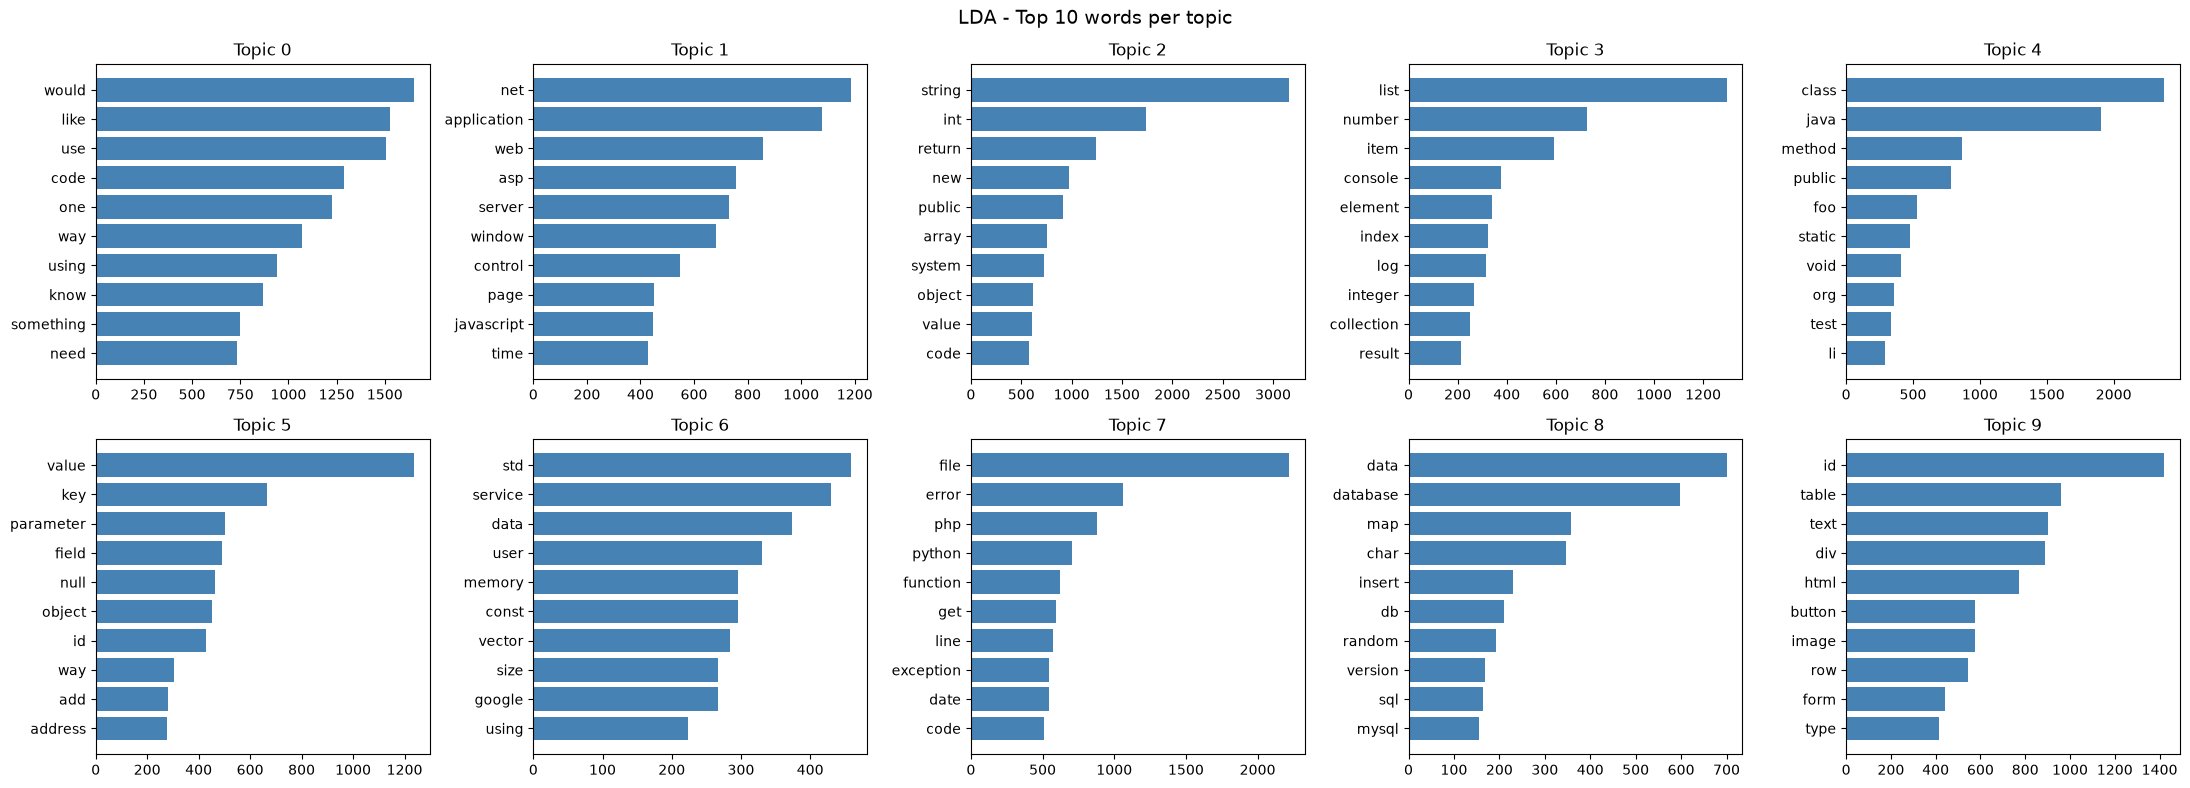

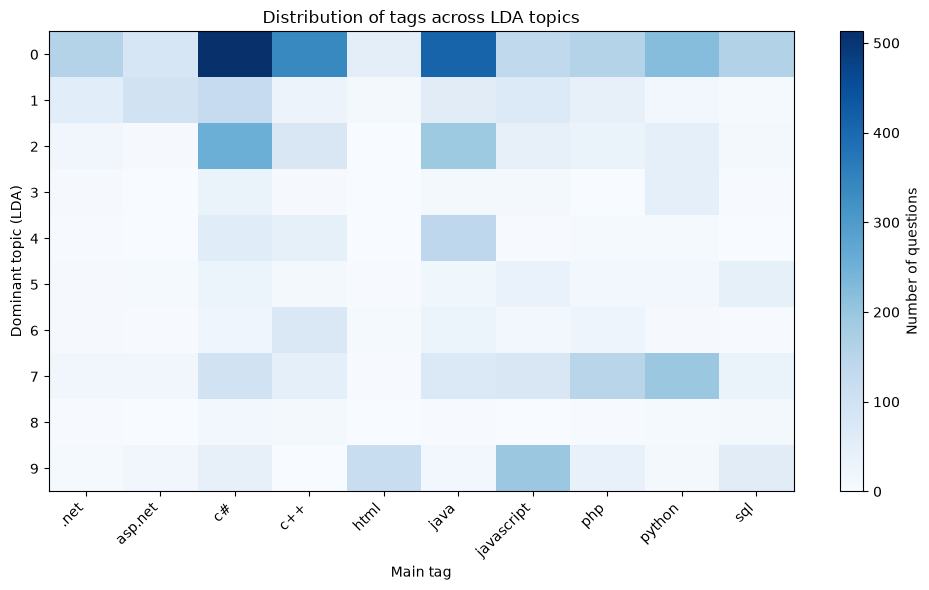

In [17]:
## Graphics to illustrate the LDA results

# 1. Top 10 words per topic (bar charts)
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
for topic_idx, (topic, ax) in enumerate(zip(lda.components_, axes.flatten())):
    top_idx = topic.argsort()[:-11:-1]
    ax.barh([feature_names[i] for i in top_idx][::-1], topic[top_idx][::-1], color='steelblue')
    ax.set_title(f"Topic {topic_idx}")
plt.suptitle("LDA - Top 10 words per topic", fontsize=14)
plt.tight_layout()
plt.show()

# 2. Link between dominant LDA topic and the real tags
df['dominant_topic'] = doc_topics.argmax(axis=1)
df['main_tag'] = df['tag_list_final'].apply(lambda l: l[0] if len(l) > 0 else None)
ct = pd.crosstab(df['dominant_topic'], df['main_tag'])

plt.figure(figsize=(10, 6))
plt.imshow(ct, aspect='auto', cmap='Blues')
plt.colorbar(label='Number of questions')
plt.xticks(range(len(ct.columns)), ct.columns, rotation=45, ha='right')
plt.yticks(range(len(ct.index)), ct.index)
plt.xlabel('Main tag')
plt.ylabel('Dominant topic (LDA)')
plt.title('Distribution of tags across LDA topics')
plt.tight_layout()
plt.show()

### 5. **Supervised approach**

In [18]:
# TODO :=> apply word embeddings and supervised approaches

## --- Target preparation : multi-label binarization + train/test split ---
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split

mlb = MultiLabelBinarizer(classes=most_frequent_tags)
y = mlb.fit_transform(df['tag_list_final'])
print("Target shape :", y.shape, "| labels :", list(mlb.classes_))

idx_train, idx_test = train_test_split(np.arange(len(df)), test_size=0.2, random_state=42)
y_train, y_test = y[idx_train], y[idx_test]
print("Train :", len(idx_train), "| Test :", len(idx_test))

## --- Feature extraction 1 : Bag-of-words (TF-IDF) ---
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(df['text'].iloc[idx_train])
X_test_tfidf  = tfidf.transform(df['text'].iloc[idx_test])
print("TF-IDF features :", X_train_tfidf.shape)

Target shape : (5447, 10) | labels : ['c#', 'java', 'c++', '.net', 'javascript', 'python', 'php', 'sql', 'html', 'asp.net']
Train : 4357 | Test : 1090
TF-IDF features : (4357, 5000)


In [19]:
## --- Feature extraction 2 : Word2Vec (average of word vectors per document) ---
from gensim.models import Word2Vec

tokens_train = [t.split() for t in df['text'].iloc[idx_train]]
tokens_test  = [t.split() for t in df['text'].iloc[idx_test]]

w2v = Word2Vec(sentences=tokens_train, vector_size=300, window=5,
               min_count=3, workers=4, seed=42, epochs=20)

def doc_vector(tokens, model):
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vecs, axis=0) if len(vecs) > 0 else np.zeros(model.vector_size)

X_train_w2v = np.vstack([doc_vector(t, w2v) for t in tokens_train])
X_test_w2v  = np.vstack([doc_vector(t, w2v) for t in tokens_test])
print("Word2Vec features :", X_train_w2v.shape)

## --- Feature extraction 3 : BERT sentence embeddings ---
from sentence_transformers import SentenceTransformer

bert = SentenceTransformer('all-MiniLM-L6-v2')
X_train_bert = bert.encode(df['text_light'].iloc[idx_train].tolist(), show_progress_bar=True)
X_test_bert  = bert.encode(df['text_light'].iloc[idx_test].tolist(), show_progress_bar=True)
print("BERT features :", X_train_bert.shape)

## --- Supervised models : Logistic Regression (OneVsRest) & XGBoost (MultiOutputClassifier) ---
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.multioutput import MultiOutputClassifier
from xgboost import XGBClassifier

features = {
    'TF-IDF'  : (X_train_tfidf, X_test_tfidf),
    'Word2Vec': (X_train_w2v, X_test_w2v),
    'BERT'    : (X_train_bert, X_test_bert),
}

def make_models():
    return {
        'LogisticRegression': OneVsRestClassifier(LogisticRegression(max_iter=1000)),
        'XGBoost': MultiOutputClassifier(XGBClassifier(n_estimators=200, max_depth=6,
                                                       learning_rate=0.1, eval_metric='logloss')),
    }

trained = {}
for feat_name, (X_tr, X_te) in features.items():
    for model_name, model in make_models().items():
        print(f"Training {model_name} on {feat_name} ...")
        model.fit(X_tr, y_train)
        trained[(feat_name, model_name)] = model
print("Done :", len(trained), "models trained")

## --- Hyperparameter tuning (example : TF-IDF + Logistic Regression) ---
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(OneVsRestClassifier(LogisticRegression(max_iter=1000)),
                    param_grid={'estimator__C': [0.1, 1, 10]},
                    scoring='f1_micro', cv=3, n_jobs=-1)
grid.fit(X_train_tfidf, y_train)
print("Best params :", grid.best_params_, "| best CV f1_micro :", round(grid.best_score_, 3))
trained[('TF-IDF', 'LogisticRegression')] = grid.best_estimator_

Word2Vec features : (4357, 300)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/137 [00:00<?, ?it/s]

Batches:   0%|          | 0/35 [00:00<?, ?it/s]

BERT features : (4357, 384)
Training LogisticRegression on TF-IDF ...
Training XGBoost on TF-IDF ...
Training LogisticRegression on Word2Vec ...
Training XGBoost on Word2Vec ...
Training LogisticRegression on BERT ...
Training XGBoost on BERT ...
Done : 6 models trained
Best params : {'estimator__C': 10} | best CV f1_micro : 0.634


### 6. **Evaluation/Comparison**

In [20]:
# TODO :=> Evaluate & compare models
from sklearn.metrics import f1_score, hamming_loss, jaccard_score, accuracy_score, classification_report

results = []
for (feat_name, model_name), model in trained.items():
    y_pred = model.predict(features[feat_name][1])
    results.append({
        'features'        : feat_name,
        'model'           : model_name,
        'f1_micro'        : f1_score(y_test, y_pred, average='micro'),
        'f1_macro'        : f1_score(y_test, y_pred, average='macro'),
        'jaccard'         : jaccard_score(y_test, y_pred, average='samples', zero_division=0),
        'hamming_loss'    : hamming_loss(y_test, y_pred),
        'subset_accuracy' : accuracy_score(y_test, y_pred),
    })

results_df = pd.DataFrame(results).sort_values('f1_micro', ascending=False).reset_index(drop=True)
results_df.round(3)

,features,model,f1_micro,f1_macro,jaccard,hamming_loss,subset_accuracy
0,BERT,LogisticRegression,0.820,0.798,0.762,0.038,0.696
1,BERT,XGBoost,0.779,0.748,0.702,0.045,0.646
2,TF-IDF,XGBoost,0.732,0.731,0.644,0.054,0.575
3,Word2Vec,LogisticRegression,0.708,0.699,0.595,0.057,0.530
4,TF-IDF,LogisticRegression,0.697,0.693,0.596,0.060,0.530
5,Word2Vec,XGBoost,0.694,0.693,0.581,0.059,0.524


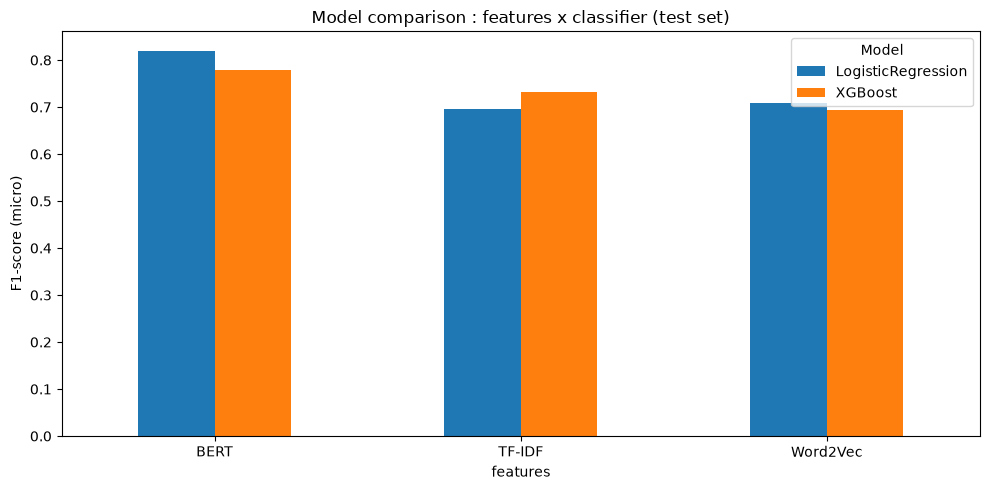

Best combination : BERT + LogisticRegression (f1_micro = 0.820)

              precision    recall  f1-score   support

          c#       0.80      0.70      0.75       228
        java       0.96      0.86      0.91       201
         c++       0.99      0.87      0.93       131
        .net       0.58      0.30      0.40       112
  javascript       0.93      0.91      0.92       137
      python       0.99      0.89      0.94       114
         php       0.95      0.90      0.93        93
         sql       0.96      0.83      0.89        83
        html       0.88      0.51      0.64        73
     asp.net       0.92      0.55      0.69        86

   micro avg       0.90      0.75      0.82      1258
   macro avg       0.90      0.73      0.80      1258
weighted avg       0.89      0.75      0.81      1258
 samples avg       0.80      0.79      0.78      1258



In [21]:
# Comparison chart + detailed report of the best model
pivot = results_df.pivot(index='features', columns='model', values='f1_micro')
pivot.plot(kind='bar', figsize=(10, 5), rot=0)
plt.ylabel('F1-score (micro)')
plt.title('Model comparison : features x classifier (test set)')
plt.legend(title='Model')
plt.tight_layout()
plt.show()

best = results_df.iloc[0]
print(f"Best combination : {best['features']} + {best['model']} (f1_micro = {best['f1_micro']:.3f})\n")
y_pred_best = trained[(best['features'], best['model'])].predict(features[best['features']][1])
print(classification_report(y_test, y_pred_best, target_names=mlb.classes_, zero_division=0))